In [275]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [276]:
db_path = "../Data/logs_output.db"
conn = sqlite3.connect(db_path)

In [277]:
sql_query = "SELECT * FROM log_record"

In [278]:
df = pd.read_sql_query(sql_query, conn)

In [279]:
df.head()

,timestamp,level,user_id,action,latency_ms,error_code
0,2026-10-10 22:05:48,INFO,user_170,login,37,0
1,2026-10-10 22:05:49,INFO,user_252,add_cart,75,0
2,2026-10-10 22:05:50,INFO,user_682,pay,86,0
3,2026-10-10 22:05:53,INFO,user_174,view_item,38,0
4,2026-10-10 22:05:54,INFO,user_178,add_cart,77,0


In [280]:
df["level"].value_counts()

level
INFO     8540
ERROR     904
WARN      556
Name: count, dtype: int64

In [281]:
df["action"].value_counts()

action
add_cart     2527
login        2526
pay          2484
view_item    2463
Name: count, dtype: int64

In [282]:
df["latency_ms"].mean()

np.float64(109.2744)

In [283]:
df["latency_ms"].median()

np.float64(61.0)

In [284]:
df["latency_ms"].max()

np.int64(1500)

In [285]:
df["latency_ms"].min()

np.int64(20)

In [286]:
df["latency_ms"].quantile(0.95)

np.float64(100.0)

In [287]:
df.groupby("action")["latency_ms"].agg(["mean", "max"])

,mean,max
action,,
add_cart,102.084685,1481
login,116.298892,1500
pay,112.578502,1492
view_item,106.114495,1489


In [288]:
error_quantity = (df["level"] == "ERROR").sum()
error_quantity / len(df)

np.float64(0.0904)

In [289]:
slow_quantity = (df["latency_ms"] > 800).sum()
slow_quantity / len(df)

np.float64(0.0448)

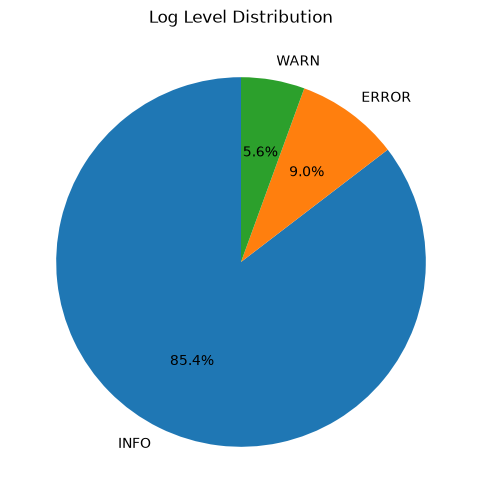

In [290]:
level_counts = df["level"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Log Level Distribution")
plt.savefig("../Data/level_pie.png")
plt.show()

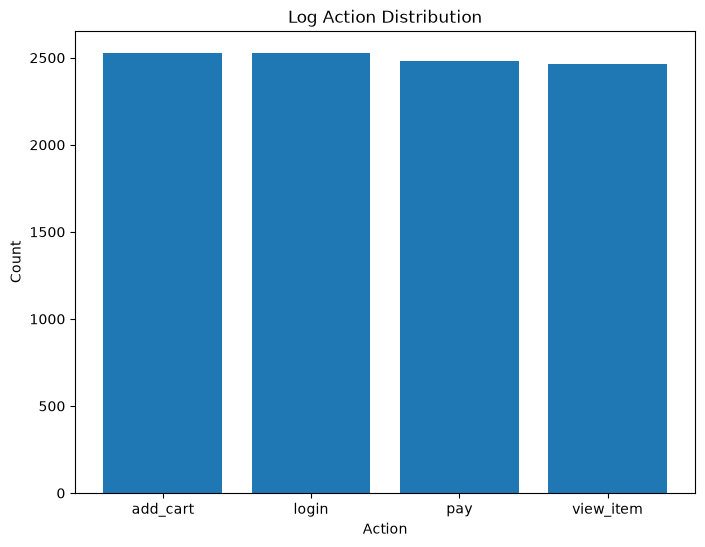

In [291]:
action_counts = df["action"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(action_counts.index, action_counts)
plt.xlabel("Action")
plt.ylabel("Count")
plt.title("Log Action Distribution")
plt.savefig("../Data/action_bar.png")
plt.show()

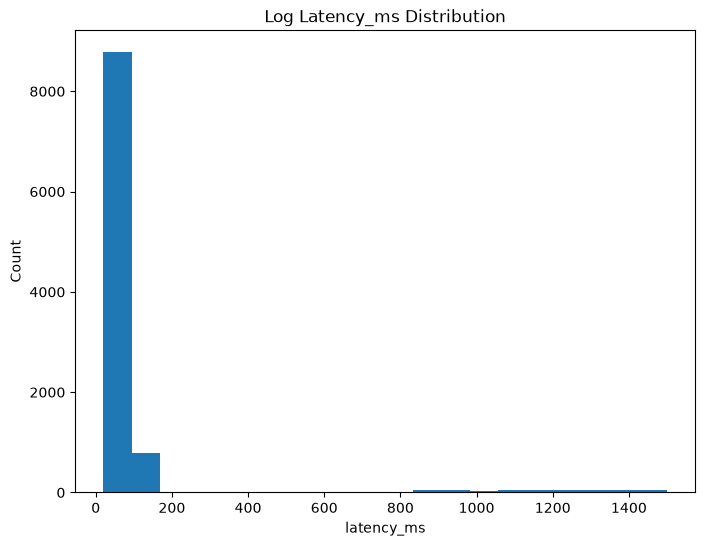

In [292]:
plt.figure(figsize=(8, 6))
plt.hist(df["latency_ms"], bins=20)
plt.xlabel("latency_ms")
plt.ylabel("Count")
plt.title("Log Latency_ms Distribution")
plt.savefig("../Data/latency_hist.png")
plt.show()

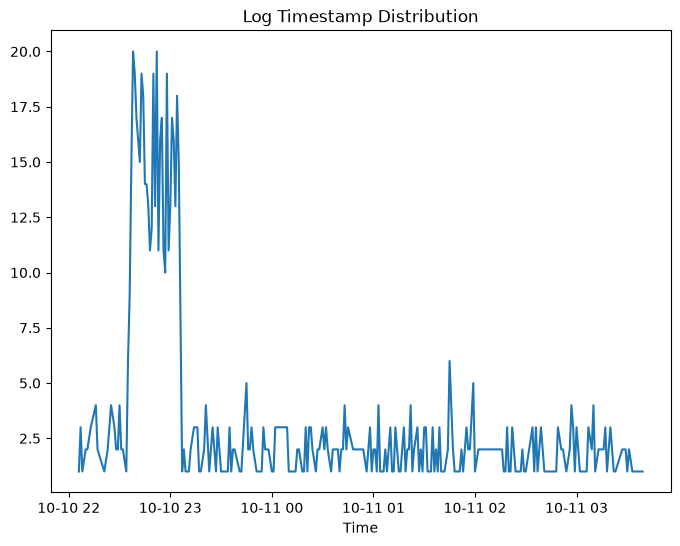

In [293]:
df["time"] = pd.to_datetime(df["timestamp"])
error_df = df[df["level"] == "ERROR"]
minute_counts = error_df.groupby(error_df["time"].dt.floor("min")).size()
plt.figure(figsize = (8, 6))
plt.plot(minute_counts.index, minute_counts.values)
plt.xlabel("Time")
plt.title("Log Timestamp Distribution")
plt.savefig("../Data/timestamp_error.png")
plt.show()

In [294]:
df["time"] = pd.to_datetime(df["timestamp"])
df = df.set_index("time")
df.index

DatetimeIndex(['2026-10-10 22:05:48', '2026-10-10 22:05:49',
               '2026-10-10 22:05:50', '2026-10-10 22:05:53',
               '2026-10-10 22:05:54', '2026-10-10 22:05:55',
               '2026-10-10 22:05:56', '2026-10-10 22:05:59',
               '2026-10-10 22:06:01', '2026-10-10 22:06:03',
               ...
               '2026-10-11 03:39:11', '2026-10-11 03:39:12',
               '2026-10-11 03:39:15', '2026-10-11 03:39:16',
               '2026-10-11 03:39:19', '2026-10-11 03:39:21',
               '2026-10-11 03:39:24', '2026-10-11 03:39:27',
               '2026-10-11 03:39:30', '2026-10-11 03:39:33'],
              dtype='datetime64[us]', name='time', length=10000, freq=None)

In [295]:
error_counts = (df["level"] == "ERROR").resample("10min").sum()
p95_latency = df["latency_ms"].resample("10min").quantile(0.95)
error_counts.head(10)

time
2026-10-10 22:00:00      5
2026-10-10 22:10:00     13
2026-10-10 22:20:00     17
2026-10-10 22:30:00     78
2026-10-10 22:40:00    149
2026-10-10 22:50:00    147
2026-10-10 23:00:00     96
2026-10-10 23:10:00     11
2026-10-10 23:20:00     20
2026-10-10 23:30:00     12
Freq: 10min, Name: level, dtype: int64

In [296]:
window_size = 3
roll_mean = error_counts.rolling(window=window_size, min_periods=1).mean()
roll_std = error_counts.rolling(window=window_size, min_periods=1).std()
roll_mean = roll_mean.shift(1)
roll_std = roll_std.shift(1)
threshold = roll_mean + 4 * roll_std
roll_mean.head()

time
2026-10-10 22:00:00          NaN
2026-10-10 22:10:00     5.000000
2026-10-10 22:20:00     9.000000
2026-10-10 22:30:00    11.666667
2026-10-10 22:40:00    36.000000
Freq: 10min, Name: level, dtype: float64

In [297]:
is_anomaly = error_counts[1:] > threshold[1:]
anomalies = error_counts[1:][is_anomaly]
print(f" !!! 发现 {len(anomalies)} 个异常时间点")
anomalies

 !!! 发现 2 个异常时间点


time
2026-10-10 22:30:00    78
2026-10-11 00:00:00    23
Name: level, dtype: int64

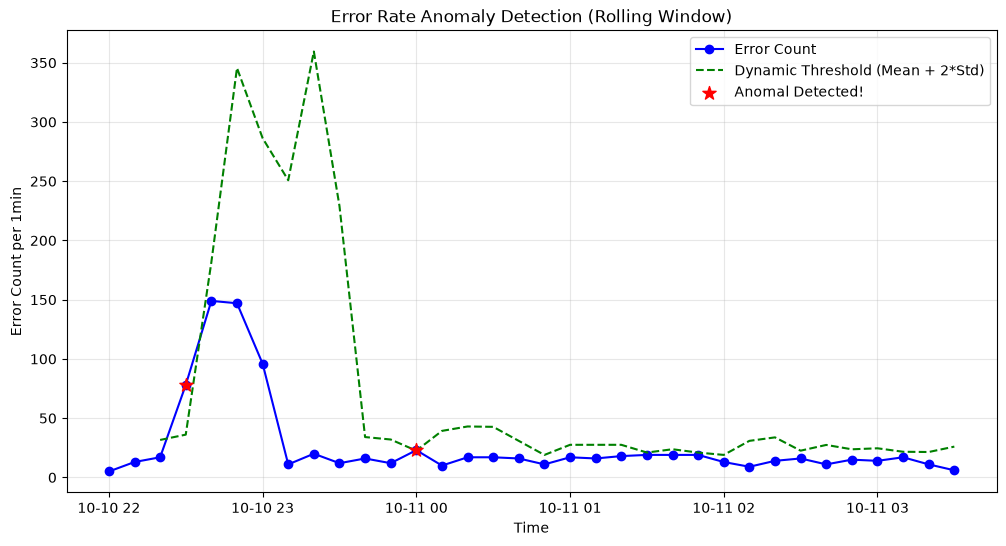

In [298]:
plt.figure(figsize=(12, 6))
plt.plot(error_counts.index, error_counts.values, label="Error Count", color="blue", marker="o")
plt.plot(threshold.index, threshold.values, label="Dynamic Threshold (Mean + 2*Std)", color="green", linestyle="--")
plt.scatter(anomalies.index, anomalies.values, color="red", s=100, marker="*", label="Anomal Detected!", zorder=5)
plt.title("Error Rate Anomaly Detection (Rolling Window)")
plt.xlabel("Time")
plt.ylabel("Error Count per 1min")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../Data/anomaly_detection.png")
plt.show()

In [299]:
conn.close()